### MLP on MNIST

In [12]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [7]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
num_samples_train, img_rows, img_cols = x_train.shape
x_train = x_train.reshape(-1, img_rows*img_cols)/255
x_test = x_test.reshape(-1, img_rows*img_cols)/255

# num_samples_test, _, _ = x_train.shape
# x_train = x_train.reshape(num_samples_train, img_rows*img_cols)/255
# x_test = x_test.reshape(num_samples_test, img_rows*img_cols)/255

In [ ]:
# Build the MLP (Sequential API)
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)  # logits (no softmax)
])
# Why no softmax?
# Because using SparseCategoricalCrossentropy(from_logits=True) automatically handles it.

In [9]:
# Compile (Loss + Optimizer + Metrics)
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

In [10]:
# train the model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9103 - loss: 0.3006 - val_accuracy: 0.9675 - val_loss: 0.1100
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9591 - loss: 0.1353 - val_accuracy: 0.9735 - val_loss: 0.0879
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9678 - loss: 0.1014 - val_accuracy: 0.9778 - val_loss: 0.0779
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9724 - loss: 0.0840 - val_accuracy: 0.9782 - val_loss: 0.0775
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9764 - loss: 0.0723 - val_accuracy: 0.9778 - val_loss: 0.0710


In [11]:
# evauate on test set
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9765 - loss: 0.0764


[0.07642889767885208, 0.9764999747276306]

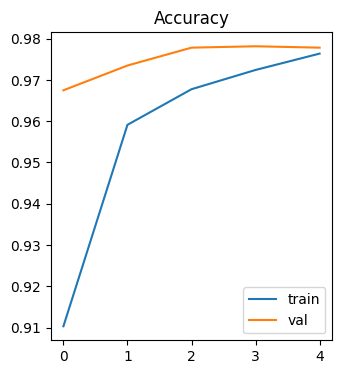

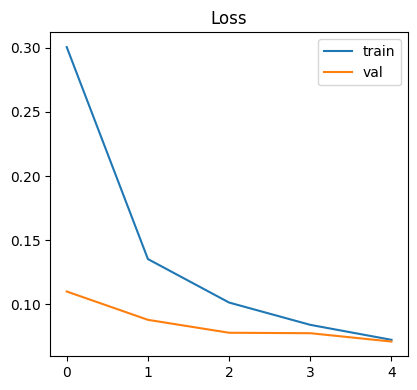

In [26]:
# Plotting Loss & Accuracy Curves
plt.figure(figsize=(8, 4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['train','val'])

plt.figure(figsize=(8, 4))
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(['train','val'])

plt.tight_layout()
plt.show()

Further Hands on Practice:
1. Try different model sizes
   - change 256 → 512
   - add a new layer
   - remove a layer
2. Add L2 Regularization
   ```python
   layers.Dense(256, activation='relu',
               kernel_regularizer=tf.keras.regularizers.l2(0.001))
   ```
3. Change Optimizer
   - SGD
   - RMSprop
   - Adam
   ```python
   optimizer=tf.keras.optimizers.SGD(0.01)
   ```
4. EarlyStopping
   ```python
   from tensorflow.keras.callbacks import EarlyStopping

   cb = EarlyStopping(patience=2, restore_best_weights=True)
   model.fit(..., callbacks=[cb])
   ```